# 03 Intervalos de Confiança (Amostras Grandes) - Prática em Python

Material conceitual (teoria): `conceitos/03_estimacao_intervalar_amostras_grandes.md`

Este notebook reúne exemplos computacionais para ICs de média e proporção com $n>30$.

## Parte A: IC para a média populacional $\mu$

### 1) Valor crítico na normal padrão

Vamos obter valores críticos com `scipy.stats.norm.ppf`.

In [1]:
import scipy.stats as st

print(st.norm.ppf(0.025))
print(st.norm.ppf(0.975))
print(st.norm.ppf(0.95 + 0.025))

-1.9599639845400545
1.959963984540054
1.959963984540054


### 2) Exemplo 1 (95%)

Dados: `x̄ = 1.58`, `s = 0.2`, `n = 100`.

In [2]:
import numpy as np
import scipy.stats as st

x_bar = 1.58
s = 0.2
desvp_bar = s / np.sqrt(100)

confidence_level = 0.95
z_score = np.abs(st.norm.ppf((1 - confidence_level)/2))

error_margin = desvp_bar * z_score

print("IC: [%.2f, %.2f]" % (x_bar-error_margin, x_bar+error_margin))

IC: [1.54, 1.62]


Checagens rápidas relacionadas à normal padrão:

In [13]:
st.norm.ppf(.025)

-1.9599639845400545

In [15]:
st.norm.cdf(-1.96)

0.024997895148220435

In [16]:
st.norm.cdf(0)

0.5

Alternativa direta para IC da média com `st.norm.interval`:

In [3]:
import numpy as np
import scipy.stats as st

# create 95% confidence interval for population mean
ic = st.norm.interval(confidence=confidence_level,
                 loc=x_bar,
                 scale=desvp_bar)
print("IC: [%.2f, %.2f]" % ic)

IC: [1.54, 1.62]


### 3) Exemplo 2 (85%)

Dados: `x̄ = 12.05`, `s = 0.1`, `n = 100`.

In [4]:
n = 100
confidence_level = .85
x_bar = 12.05
s = 0.1
desvp_x_bar = s / np.sqrt(n)
ic = st.norm.interval(confidence=confidence_level,
                 loc=x_bar,
                 scale=desvp_x_bar)
print("IC: [%.2f, %.2f]" % ic)

IC: [12.04, 12.06]


### 4) Exemplo 3 (90%)

Dados: `x̄ = 7.71`, `s = 1.51`, `n = 150`.

In [5]:
import numpy as np
import scipy.stats as st

n = 150

# passo 1 - computar média amostral
x_bar = 7.71

# passo 2 - computar desvio padrão de média amostral
s = 1.51
desvp_bar = s / np.sqrt(n)

# passo 3 - computar valor crítico
nivel_confianca = .90
valor_critico = st.norm.ppf((1-nivel_confianca)/2)

# passo 4 - computar limites do IC
i = x_bar - np.abs(valor_critico) * desvp_bar
f = x_bar + np.abs(valor_critico) * desvp_bar

print("IC no nível de 90%%: [%.2f, %.2f]" % (i,f))

IC no nível de 90%: [7.51, 7.91]


In [6]:
ic = st.norm.interval(confidence = nivel_confianca, loc = x_bar, scale = desvp_bar)
print("IC no nível de 90%%: [%.2f, %.2f]" % (ic[0],ic[1]))

IC no nível de 90%: [7.51, 7.91]


## Parte B: IC para proporção populacional $p$

### 5) Simulação da distribuição amostral de `p̂`

Vamos simular variáveis Bernoulli e observar como a distribuição de `p̂` muda com `n`.

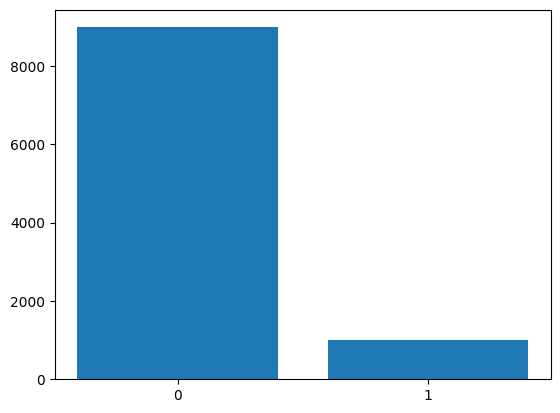

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import bernoulli
data_bern = bernoulli.rvs(size=10000,p=0.1)
data_bern

sample = data_bern
labels, counts = np.unique(sample, return_counts=True)
plt.bar(labels, counts, align='center')
plt.gca().set_xticks(labels)
plt.show()

In [8]:
from numpy.random import seed
from numpy.random import randint
from numpy import mean, std
import numpy as np
from matplotlib import pyplot
import random

def build_hist(n):
  num_amostras = 10000
  proportions = [mean(bernoulli.rvs(size=n,p=0.1)) for _ in range(num_amostras)]
  return proportions

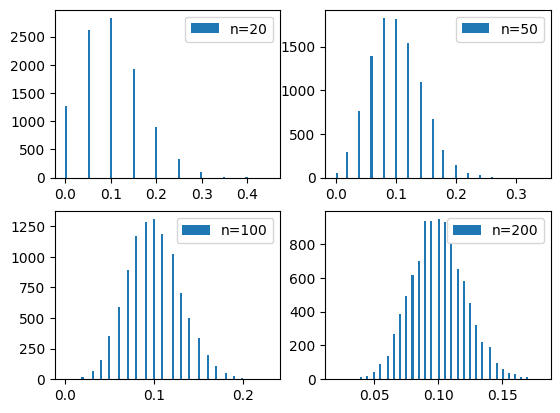

In [9]:
fig, axs = plt.subplots(2, 2)
proportions = build_hist(20)
axs[0, 0].hist(proportions, bins=100, label="n=20")
axs[0, 0].legend(loc='upper right')

proportions = build_hist(50)
axs[0, 1].hist(proportions, bins=100, label="n=50")
axs[0, 1].legend(loc='upper right')

proportions = build_hist(100)
axs[1, 0].hist(proportions, bins=100, label="n=100")
axs[1, 0].legend(loc='upper right')

proportions = build_hist(200)
axs[1, 1].hist(proportions, bins=100, label="n=200")
axs[1, 1].legend(loc='upper right')

### 6) Exemplo de IC para proporção (99%)

Dados: `p̂ = 0.40`, `n = 1600`.

In [10]:
from scipy.stats import norm
norm.ppf(.005 + 0.99)

2.5758293035489004

In [11]:
from scipy.stats import norm
import numpy as np

confidence_level = 0.99

alfa = 1 - confidence_level

critical_value = np.absolute(norm.ppf(alfa/2))
print("critical value: %.2f" % critical_value)

p_hat = .4
n = 1600
errorMargin = critical_value * np.sqrt((p_hat*(1-p_hat))/n)
lowerBound = p_hat - errorMargin
upperBound = p_hat + errorMargin
print("99 percent CI: (%.2f,%.2f)" % (lowerBound, upperBound))

critical value: 2.58
99 percent CI: (0.37,0.43)


In [12]:
n = 1600
confidence_level = .99
p_hat = .4
desvp_p_hat = np.sqrt((p_hat*(1-p_hat))/n)
st.norm.interval(confidence = confidence_level,
                 loc = p_hat,
                 scale = desvp_p_hat)

(0.3684526627089832, 0.43154733729101685)

## Leitura dos resultados

1. Compare a largura dos ICs quando o nível de confiança muda.
2. Em proporções, observe o efeito de `n` no estreitamento dos intervalos.
3. Use o material conceitual para revisar fórmulas e hipóteses de uso.

## Parte C: Dimensionamento amostral

Agora vamos calcular o tamanho mínimo de amostra para estimar `μ` e `p` com margem de erro alvo.

In [ ]:
import math
from scipy.stats import norm


def n_min_media(E, confidence_level=0.95, sigma=None, s=None):
    """Tamanho mínimo de amostra para IC da média."""
    if sigma is None and s is None:
        raise ValueError("Forneça sigma (populacional) ou s (estimado em piloto).")
    sigma_eff = sigma if sigma is not None else s
    z = abs(norm.ppf((1 - confidence_level) / 2))
    return math.ceil((sigma_eff**2) * (z**2) / (E**2))


def n_min_proporcao(E, confidence_level=0.95, p=None, p_piloto=None):
    """Tamanho mínimo de amostra para IC da proporção."""
    z = abs(norm.ppf((1 - confidence_level) / 2))
    if p is None and p_piloto is None:
        # caso conservador: p(1-p) <= 1/4
        return math.ceil((z**2) / (4 * E**2))
    p_eff = p if p is not None else p_piloto
    return math.ceil((z**2) * p_eff * (1 - p_eff) / (E**2))

### Exemplos rápidos

In [ ]:
# Exemplo 1: média (sigma conhecido)
print("n para média (E=500, 95%, sigma=6250):", n_min_media(E=500, confidence_level=0.95, sigma=6250))
print("n para média (E=1000, 95%, sigma=6250):", n_min_media(E=1000, confidence_level=0.95, sigma=6250))

# Exemplo 2: proporção com estimativa prévia p=0.60
print("n para proporção (E=0.03, 95%, p=0.60):", n_min_proporcao(E=0.03, confidence_level=0.95, p=0.60))

# Exemplo 3: proporção sem estimativa prévia (conservador)
print("n para proporção (E=0.01, 95%, sem p prévio):", n_min_proporcao(E=0.01, confidence_level=0.95))

### Exercício sugerido

Altere `E` e o nível de confiança e observe a sensibilidade do tamanho amostral. Em especial, compare o efeito de reduzir `E` pela metade.